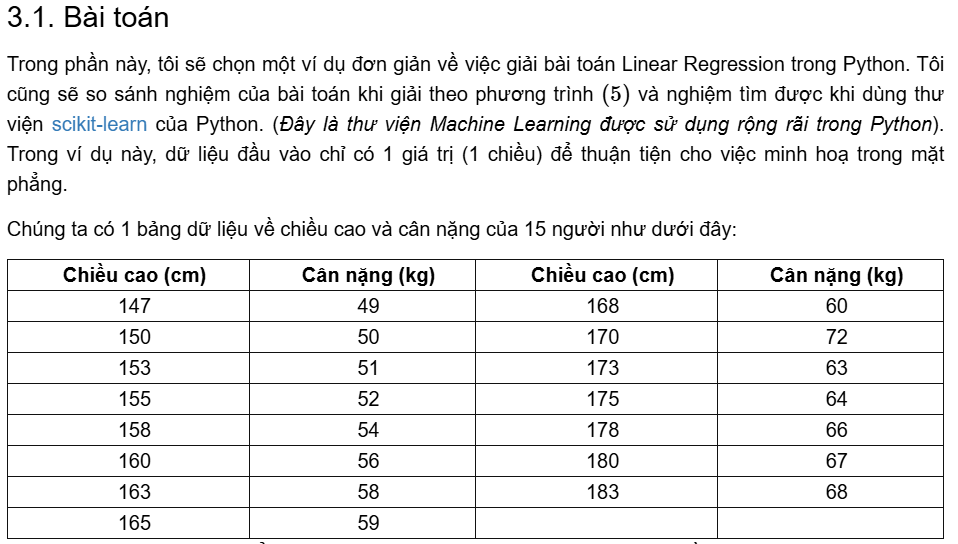

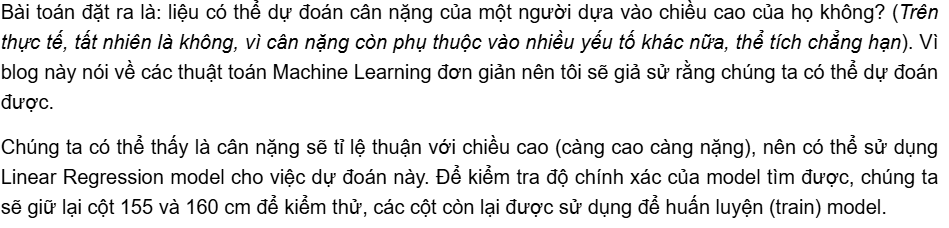

Thuật toán Hồi quy tuyến tính (Linear Regression) giúp tìm ra một mô hình tuyến tính dự đoán kết quả đầu ra dựa trên các giá trị đầu vào. Trong ví dụ này, thuật toán được sử dụng để dự đoán cân nặng của một người dựa vào chiều cao.Hàm mất mát của bài toán:$$L(w) = \frac{1}{2} \|y - \bar{X}w\|_2^2$$Nghiệm tối ưu cho phương trình đạo hàm bằng 0 được tính thông qua ma trận giả nghịch đảo:$$w = (\bar{X}^T \bar{X})^{\dagger} \bar{X}^T y$$

## Bước 1: Khai báo thư viện và dữ liệu

In [ ]:
from __future__ import division, print_function, unicode_literals
import numpy as np 
import matplotlib.pyplot as plt

# height (cm)
X = np.array([[147, 150, 153, 158, 163, 165, 168, 170, 173, 175, 178, 180, 183]]).T
# weight (kg)
y = np.array([[ 49, 50, 51,  54, 58, 59, 60, 62, 63, 64, 66, 67, 68]]).T

## Bước 2: Hiển thị dữ liệu thô trên đồ thị

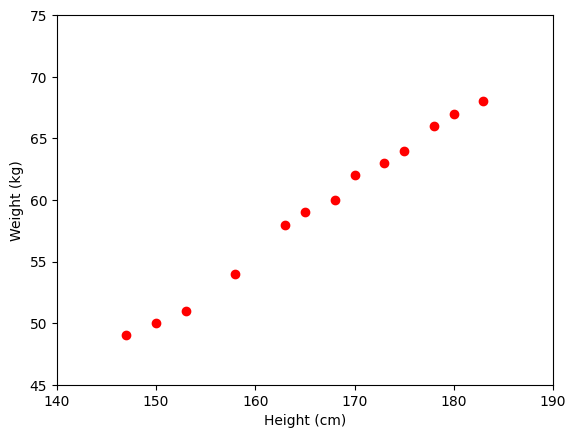

In [ ]:
# Visualize data 
plt.plot(X, y, 'ro')
plt.axis([140, 190, 45, 75])
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.show()

## Bước 3: Tìm nghiệm theo công thức toán học

Tính toán hệ số của đường thẳng dựa trên công thức giả nghịch đảo, sau đó vẽ đường thẳng dự đoán đè lên tập dữ liệu ban đầu.

w =  [[-33.73541021]
 [  0.55920496]]


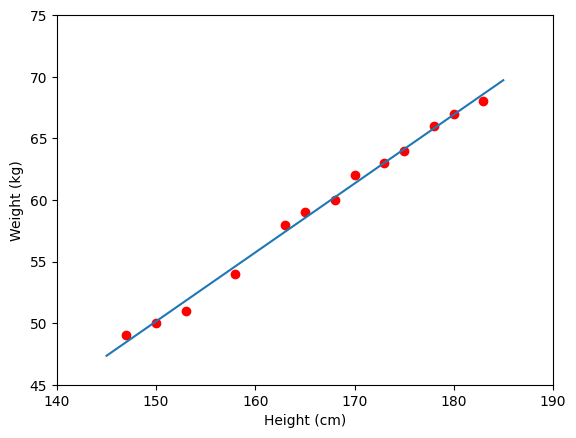

In [9]:
# Building Xbar 
one = np.ones((X.shape[0], 1))
Xbar = np.concatenate((one, X), axis = 1)

# Calculating weights of the fitting line 
A = np.dot(Xbar.T, Xbar)
b = np.dot(Xbar.T, y)
w = np.dot(np.linalg.pinv(A), b)
print('w = ', w)
# Preparing the fitting line 
w_0 = w[0][0]
w_1 = w[1][0]
x0 = np.linspace(145, 185, 2)
y0 = w_0 + w_1*x0

# Drawing the fitting line 
plt.plot(X.T, y.T, 'ro')     # data 
plt.plot(x0, y0)               # the fitting line
plt.axis([140, 190, 45, 75])
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.show()

## Bước 4: Dự đoán thử nghiệm

Dùng trọng số vừa tìm được để dự đoán cân nặng cho hai chiều cao chưa từng xuất hiện trong tập huấn luyện (155 cm và 160 cm).

In [10]:
y1 = w_1*155 + w_0
y2 = w_1*160 + w_0

print( u'Predict weight of person with height 155 cm: %.2f (kg), real number: 52 (kg)'  %(y1) )
print( u'Predict weight of person with height 160 cm: %.2f (kg), real number: 56 (kg)'  %(y2) )

Predict weight of person with height 155 cm: 52.94 (kg), real number: 52 (kg)
Predict weight of person with height 160 cm: 55.74 (kg), real number: 56 (kg)


## Bước 5: Đối chiếu với thư viện Scikit-Learn

Sử dụng thư viện chuẩn của Python để kiểm tra xem nghiệm tính bằng tay ở trên có chính xác tuyệt đối không.

In [11]:
from sklearn import datasets, linear_model

# fit the model by Linear Regression
regr = linear_model.LinearRegression(fit_intercept=False) # fit_intercept = False for calculating the bias
regr.fit(Xbar, y)

# Compare two results
print( 'Solution found by scikit-learn  : ', regr.coef_ )
print( 'Solution found by (5): ', w.T)

Solution found by scikit-learn  :  [[-33.73541021   0.55920496]]
Solution found by (5):  [[-33.73541021   0.55920496]]
